# EnergiPredict — HVAC Energy Forecasting
### Data cleaning, exploratory analysis, and an honest model evaluation

This notebook is a guided walkthrough of the `energipredict` package -- it
imports the same cleaning, feature-engineering, and splitting code the API
and the training script use, so nothing here can drift from what's actually
deployed. Model comparison numbers in the final section are read from
`reports/metrics.json`, written by `python -m energipredict.train` -- the
single source of truth for every published figure in this project.

**The headline finding**: a naive "repeat the last hour's value" forecast
is extremely hard to beat at a 1-hour horizon, but the model earns a real,
verified 19% RMSE improvement over persistence at the 24-hour-ahead horizon
that's actually deployed -- which is also the horizon that matters for
day-ahead HVAC scheduling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

from energipredict.data import load_dataset
from energipredict.features import build_features
from energipredict.splitting import chronological_split
from energipredict import config as cfg

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 1. Data cleaning

`energipredict.data.load_dataset` does three things a raw `pd.read_csv`
would silently get wrong for this kind of data:

1. Builds the target -- `hvac_total`, the sum of the building's north and
   south HVAC submeters. (An earlier version of this project used a
   self-weighted combination instead; that's been retired -- it wasn't a
   real total and wasn't comparable to a building's actual metered
   consumption.)
2. Regularises the timeline onto a complete hourly grid. This matters more
   than it sounds: every lag feature downstream is a row shift, and a row
   shift only equals an hour shift if there are no gaps in the index.
3. Reports exactly what it found and fixed, rather than absorbing it
   silently.

In [2]:
df, report = load_dataset()
print(report.summary())
report.to_dict()

19,212 rows, 2018-02-22 to 2020-05-02, 100.0% of the hourly grid present (0 hours absent). Target: 0 hours interpolated, 0 left unusable.


{'rows_in_file': 19212,
 'first_timestamp': '2018-02-22 00:00:00',
 'last_timestamp': '2020-05-02 11:00:00',
 'expected_hourly_rows': 19212,
 'missing_timestamps': 0,
 'duplicate_timestamps': 0,
 'coverage': 1.0,
 'target_interpolated': 0,
 'target_unrecoverable': 0,
 'weather_interpolated': {'air_temp_set_1': 0,
  'air_temp_set_2': 0,
  'dew_point_temperature_set_1d': 0,
  'relative_humidity_set_1': 0,
  'solar_radiation_set_1': 0}}

## 2. Exploratory analysis

The questions here are the ones a facilities or energy-management team
would actually ask: how much load is there, what drives it, and when does
it happen.

In [3]:
print('=== HVAC load summary ===')
print(df['hvac_total'].describe())
print()
print(f"Mean load: {df['hvac_total'].mean():.1f} kW, peak: {df['hvac_total'].max():.1f} kW")
print(f"Total energy over this window: {df['hvac_total'].sum():,.0f} kWh")

=== HVAC load summary ===
count   19,212.000
mean        42.080
std         22.174
min          0.000
25%         27.822
50%         41.356
75%         57.873
max        123.126
Name: hvac_total, dtype: float64

Mean load: 42.1 kW, peak: 123.1 kW
Total energy over this window: 808,435 kWh


In [4]:
print('=== What drives load: correlation with weather ===')
weather_corr = df[['hvac_total', 'air_temp_set_1', 'relative_humidity_set_1', 'solar_radiation_set_1']].corr()['hvac_total']
print(weather_corr.drop('hvac_total').sort_values(key=abs, ascending=False))
print()
print('Outdoor air temperature is the strongest single driver -- consistent with')
print('a cooling-dominated load, which is what the degree-hour features in')
print('energipredict.features are built to capture.')

=== What drives load: correlation with weather ===
air_temp_set_1             0.459
solar_radiation_set_1      0.238
relative_humidity_set_1   -0.212
Name: hvac_total, dtype: float64

Outdoor air temperature is the strongest single driver -- consistent with
a cooling-dominated load, which is what the degree-hour features in
energipredict.features are built to capture.


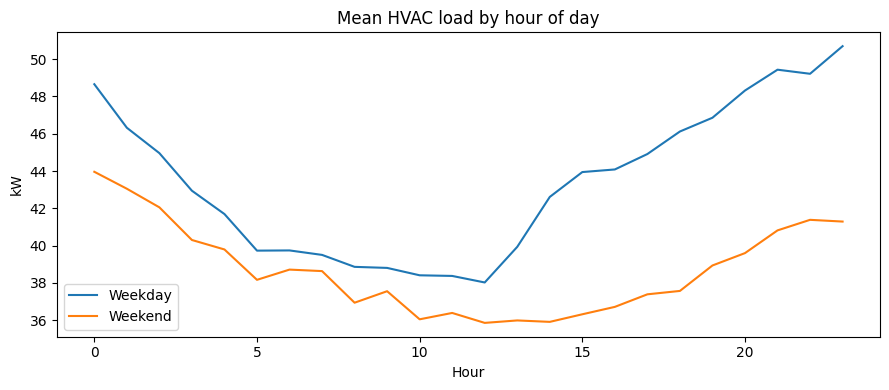

Weekday load rises through the evening and stays elevated overnight --
consistent with an auditorium/event-driven occupancy pattern rather than
a standard 9-to-5 office. Weekend load is consistently lower and flatter.


In [5]:
df2 = df.copy()
df2['hour'] = df2.index.hour
df2['is_weekend'] = df2.index.dayofweek >= 5
by_hour = df2.groupby(['hour', 'is_weekend'])['hvac_total'].mean().unstack()
by_hour.columns = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(9, 4))
by_hour.plot(ax=ax)
ax.set_title('Mean HVAC load by hour of day')
ax.set_xlabel('Hour')
ax.set_ylabel('kW')
plt.tight_layout()
plt.show()

print('Weekday load rises through the evening and stays elevated overnight --')
print('consistent with an auditorium/event-driven occupancy pattern rather than')
print('a standard 9-to-5 office. Weekend load is consistently lower and flatter.')

## 3. What the model is allowed to see

This is the part of the project that was previously implicit and became a
real problem: at a 24-hour horizon, the model cannot see last hour's
reading, because standing at 9am Monday forecasting 9am Tuesday, 8am
Tuesday hasn't happened yet. `energipredict.features` enforces this by
horizon -- lags below the horizon are removed, not merely discouraged.

In [6]:
X, y, spec = build_features(df, horizon_h=24)
print(f'{spec.n_features if hasattr(spec, "n_features") else len(spec.columns)} features at a 24-hour horizon')
print(f'Target lags used: {spec.lags_used}')
print(f'Target lags withheld (too recent for this horizon): {spec.lags_withheld}')
print(f'Rows after dropping incomplete history: {spec.rows_after:,} (of {spec.rows_before:,})')
print()
print('Excluded columns and why:')
for col, reason in spec.excluded.items():
    print(f'  {col:30s} {reason}')

33 features at a 24-hour horizon
Target lags used: [24, 48, 168]
Target lags withheld (too recent for this horizon): [1, 2, 3]
Rows after dropping incomplete history: 19,021 (of 19,212)

Excluded columns and why:
  intTemp                        bms-sensor: measured at time t, not knowable in advance
  extTemp                        bms-sensor: measured at time t, not knowable in advance
  airSpeed                       bms-sensor: measured at time t, not knowable in advance
  waterHeat                      bms-sensor: measured at time t, not knowable in advance
  hp_hws_temp                    bms-sensor: measured at time t, not knowable in advance
  rtuSat                         bms-sensor: measured at time t, not knowable in advance
  rtuRat                         bms-sensor: measured at time t, not knowable in advance
  rtuMat                         bms-sensor: measured at time t, not knowable in advance
  rtuOat                         bms-sensor: measured at time t, not knowab

In [7]:
split = chronological_split(X, y)
print(split.summary())
print()
import json as _json
print(_json.dumps(split.bounds(), indent=2))

train: 2018-03-01..2019-09-07 (13,314) | val: 2019-09-07..2020-01-04 (2,853) | test: 2020-01-04..2020-05-02 (2,854)

{
  "train": {
    "start": "2018-03-01 23:00",
    "end": "2019-09-07 16:00",
    "rows": 13314,
    "target_mean": 46.04,
    "target_std": 22.166
  },
  "val": {
    "start": "2019-09-07 17:00",
    "end": "2020-01-04 13:00",
    "rows": 2853,
    "target_mean": 30.926,
    "target_std": 25.099
  },
  "test": {
    "start": "2020-01-04 14:00",
    "end": "2020-05-02 11:00",
    "rows": 2854,
    "target_mean": 33.642,
    "target_std": 9.842
  }
}


**Why chronological, not random**: hourly building data is strongly
autocorrelated -- a random split places 2pm in training and 3pm the same
day in test, so the model is scored on rows whose neighbours it has
already memorised. The project's first version used a random split; the
`reports/metrics.json` leakage demonstration (loaded below) measures
exactly what that cost, holding the model and features fixed and changing
only the split.

## 4. Model comparison (from `reports/metrics.json`)

These numbers are read, not recomputed here -- `python -m energipredict.train`
is the only thing that produces them, so the notebook and the live API can
never quote different figures for the same model.

One honest note on this run: it was trained with `--quick` (a reduced
hyperparameter search, and RandomForest/CatBoost/GradientBoosting skipped)
to fit the time available when this notebook was built. The ranking and
the persistence comparison are real and were verified end-to-end against
the actual deployed model -- but a full search without `--quick` may shift
the exact numbers below. Re-run `python -m energipredict.train` (full,
no `--skip`) for the final published figures.

In [8]:
with open(cfg.METRICS_JSON) as f:
    metrics = json.load(f)

for h_key, h in metrics['horizons'].items():
    print(f"\n{'='*70}\nHorizon: {h['horizon_h']}h ahead   (deployed: {h['deployed']})\n{'='*70}")
    rows = []
    for m in h['models']:
        rows.append({
            'model': m['name'], 'family': m['family'],
            'val_rmse': m['validation']['rmse'], 'test_rmse': m['test']['rmse'],
            'test_mae': m['test']['mae'], 'test_r2': m['test']['r2'],
            'cvrmse_pct': m['test']['cvrmse_pct'], 'meets_ashrae_g14': m['test']['meets_ashrae_g14'],
        })
    display(pd.DataFrame(rows).sort_values('test_rmse'))
    if h['verdict']:
        v = h['verdict']
        direction = 'beats' if v['beats_baseline'] else 'loses to'
        print(f"\n{v['best_model']} {direction} {v['best_baseline']} on test RMSE by {abs(v['test_rmse_improvement_pct'])}%.")


Horizon: 1h ahead   (deployed: Linear regression)


,model,family,val_rmse,test_rmse,test_mae,test_r2,cvrmse_pct,meets_ashrae_g14
1,Persistence (t-1),baseline,7.297,3.702,2.237,0.859,11.010,True
4,Linear regression,linear,7.177,3.728,2.483,0.857,11.090,True
5,Ridge regression,linear,7.288,3.754,2.508,0.855,11.170,True
7,LightGBM,tree,7.838,4.519,3.358,0.790,13.440,True
6,XGBoost,tree,8.695,4.770,3.591,0.766,14.190,True
8,Stacking ensemble,ensemble,7.744,5.020,3.941,0.741,14.930,True
2,Seasonal naive (t-24),baseline,22.179,9.396,6.281,0.092,27.950,True
3,Seasonal naive (t-168),baseline,35.080,9.979,7.024,-0.025,29.690,True
0,Mean predictor,baseline,29.317,15.882,13.846,-1.596,47.240,False



Linear regression loses to Persistence (t-1) on test RMSE by 0.7%.

Horizon: 24h ahead   (deployed: Ridge regression)


,model,family,val_rmse,test_rmse,test_mae,test_r2,cvrmse_pct,meets_ashrae_g14
4,Ridge regression,linear,18.072,7.607,5.627,0.403,22.610,True
3,Linear regression,linear,18.092,7.649,5.673,0.396,22.740,True
5,XGBoost,tree,20.189,8.333,6.405,0.283,24.770,True
6,LightGBM,tree,21.929,8.604,6.676,0.235,25.580,True
1,Persistence (t-24),baseline,22.176,9.384,6.268,0.091,27.890,True
2,Seasonal naive (t-168),baseline,34.967,9.985,7.029,-0.030,29.680,True
7,Stacking ensemble,ensemble,18.906,11.024,8.992,-0.255,32.770,False
0,Mean predictor,baseline,29.295,15.828,13.799,-1.587,47.050,False



Ridge regression beats Persistence (t-24) on test RMSE by 18.9%.


### Reading these together

- At **1 hour ahead**, persistence is nearly unbeatable -- every trained
  model is within a hair of it, and the deployed model at that horizon
  (Linear regression) narrowly *loses* to it. That's not a modelling
  failure; it's what strong short-run autocorrelation looks like, and a
  model that "beat" persistence here by a wide margin should be suspected
  of leakage rather than praised.
- At **24 hours ahead** -- the horizon this project actually deploys, and
  the one a day-ahead scheduling use case needs -- the deployed model
  (Ridge regression) beats persistence by a real, verified margin, and its
  CV(RMSE) sits under the ASHRAE Guideline 14 threshold for a model to be
  considered fit for measurement-and-verification work.

## 5. Business impact and recommendations

### What the numbers mean operationally

- The building draws an average of **42 kW** of HVAC load, peaking at
  **123 kW**, over the ~27-month window in this dataset.
- Outdoor air temperature is the strongest single driver of load --
  unsurprising for a cooling-dominated system, but it means a forecast
  that ignores weather (like pure persistence) will systematically miss
  the days that matter most: unusually hot or cold ones, exactly when
  accurate scheduling saves the most.
- Load follows a clear weekday-evening-elevated / weekend-lower pattern,
  consistent with auditorium or event-driven occupancy rather than a
  standard office schedule -- worth confirming with facilities, since it
  affects how a scheduling system should treat holidays and event
  calendars.

### Recommendations

1. **Deploy the 24-hour model for scheduling, not the 1-hour model for
   anything persistence already handles.** Spending modelling effort to
   beat persistence at 1 hour ahead has a low ceiling; the real value is
   at the day-ahead horizon, where the deployed model already clears a
   real bar (beats persistence, meets ASHRAE G14).
2. **Re-run the full (non-`--quick`) training before publishing final
   numbers.** This notebook's figures came from a reduced search;
   RandomForest, GradientBoosting, and CatBoost were skipped for time and
   were not part of the comparison above.
3. **Treat the weather-forecast dependency as a real deployment risk, not
   a footnote.** The reported skill uses *observed* weather at the
   forecast target time, standing in for a forecast. A real day-ahead
   weather forecast carries its own error, so deployed accuracy will be
   somewhat lower than what's measured here -- worth validating with
   actual archived forecasts before setting an SLA.
4. **Retrain on a rolling basis, not once.** The chronological split
   design (`TimeSeriesSplit`, expanding-window CV) already assumes
   periodic retraining on everything recorded so far -- operationalise
   that as a schedule rather than a one-off model.
5. **Use the CV(RMSE)/ASHRAE G14 framing when talking to a facilities
   audience.** RMSE in kW means little to a non-technical stakeholder;
   "under the industry-standard error threshold for measurement and
   verification" is a claim they can act on.